In [ ]:
import re

def parse_log_file(file_path):
    """Đọc 1 file log, trả về list_1 (giá trị 0-100) của file đó."""
    list_1 = []
    with open(file_path, "r", encoding="utf-8") as file:
        for line in file:
            numbers = re.findall(r"[-+]?\d*\.\d+|\d+", line)
            if len(numbers) == 2:
                # Nếu có số thứ hai, kiểm tra điều kiện từ 0 đến 100
                val = float(numbers[1])
                if 0 <= val <= 100:
                    list_1.append(val)
    return list_1

def parse_all_logs(file_paths, start=60, end=460):
    """Nhận list các file_path, trả về list của các list_1 (đã cắt từ start đến end)."""
    all_list_1 = []
    for path in file_paths:
        list_1 = parse_log_file(path)
        all_list_1.append(list_1[start:end])   # chỉ lấy index 60 -> 459
    return all_list_1

# Danh sách các file log
file_paths = [
    "/content/drive/MyDrive/Split Inference/result/result_afternoon_11_7/dynamic/batch_done_ns.log",  # dynamic
    "/content/drive/MyDrive/Split Inference/result/result_afternoon_11_7/split/batch_done_ns.log",    # split
    "/content/drive/MyDrive/Split Inference/result/result_afternoon_11_7/standalone/batch_done_ns.log",          # standalone - compress
    "/content/drive/MyDrive/Split Inference/result/standalone-inference/non_compress/batch_done_ns.log",      # standalone - non compress
    "/content/drive/MyDrive/Split Inference/result/result_afternoon_11_7/DAG/batch_done_ns.log",              # DAG
    "/content/drive/MyDrive/Split Inference/result/result_afternoon_11_7/qa/batch_done_ns.log",                                   # QA
    "/content/drive/MyDrive/Split Inference/result/c MA/batch_done_ns.log",                                   # MA
    "/content/drive/MyDrive/Split Inference/result/privacy aware/results_non_compress/batch_done_ns.log"      # PA
]

list_name = ["dynamic", "split", "standalone - compress", "standalone - non compress", "PDD", "CPCDRL", "DMSF", "PA Joint DNN"]

all_list_1 = parse_all_logs(file_paths)   # mặc định lấy [60:460]

# In kết quả kiểm tra
for name, lst in zip(list_name, all_list_1):
    print(f"{name}:")
    print(f"  Độ dài list_1 (sau khi cắt [60:460]): {len(lst)}")
    print(f"  5 phần tử đầu: {lst[:5]}")
    print("-" * 30)

dynamic:
  Độ dài list_1 (sau khi cắt [60:460]): 400
  5 phần tử đầu: [32.49, 35.13, 33.85, 33.26, 33.32]
------------------------------
split:
  Độ dài list_1 (sau khi cắt [60:460]): 400
  5 phần tử đầu: [30.08, 35.13, 32.9, 30.55, 34.47]
------------------------------
standalone - compress:
  Độ dài list_1 (sau khi cắt [60:460]): 400
  5 phần tử đầu: [31.53, 30.32, 29.07, 28.65, 29.05]
------------------------------
standalone - non compress:
  Độ dài list_1 (sau khi cắt [60:460]): 400
  5 phần tử đầu: [28.68, 34.47, 34.63, 36.52, 33.85]
------------------------------
PDD:
  Độ dài list_1 (sau khi cắt [60:460]): 400
  5 phần tử đầu: [14.37, 14.41, 14.37, 14.33, 14.41]
------------------------------
CPCDRL:
  Độ dài list_1 (sau khi cắt [60:460]): 400
  5 phần tử đầu: [36.63, 35.05, 33.92, 37.54, 35.51]
------------------------------
DMSF:
  Độ dài list_1 (sau khi cắt [60:460]): 400
  5 phần tử đầu: [25.25, 24.41, 24.76, 25.35, 24.66]
------------------------------
PA Joint DNN:
  Độ d

dynamic: mean = 33.503, var = 11.418, std = 3.379
split: mean = 33.530, var = 2.534, std = 1.592
standalone - compress: mean = 29.394, var = 8.931, std = 2.989
standalone - non compress: mean = 29.375, var = 15.697, std = 3.962
PDD: mean = 14.845, var = 0.106, std = 0.326
CPCDRL: mean = 32.132, var = 26.911, std = 5.188
DMSF: mean = 23.765, var = 1.116, std = 1.056
PA Joint DNN: mean = 21.814, var = 26.840, std = 5.181


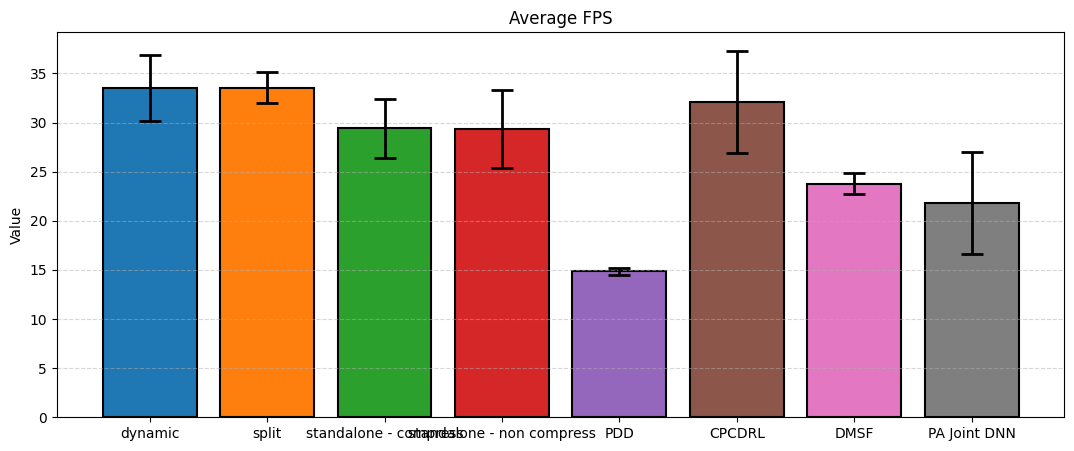

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def compute_mean(data):
    return np.mean(data)

def compute_var(data):
    return np.var(data)      # add ddof=1 for sample variance

def compute_std(data):
    return np.std(data)      # add ddof=1 for sample std

def compute_stats(list_of_lists , save=False):
    """Return means, variances, stds for a list of lists."""
    means = [compute_mean(d) for d in list_of_lists]
    vars_ = [compute_var(d) for d in list_of_lists]
    stds  = [compute_std(d) for d in list_of_lists]
    return means, vars_, stds

def visualize_means(list_of_lists, labels=None , save=False):
    means, _, stds = compute_stats(list_of_lists)
    n = len(list_of_lists)

    if labels is None:
        labels = [f"List {i+1}" for i in range(n)]

    colors = plt.cm.tab10.colors  # up to 10 distinct colors, cycles after

    plt.figure(figsize=(1.5 * n + 1, 5))
    plt.bar(labels, means, yerr=stds, capsize=8,
            color=[colors[i % 10] for i in range(n)],
            edgecolor="black", linewidth=1.5,
            error_kw={"elinewidth": 2, "capthick": 2})

    OUTPUT_PATH = "Average_FPS.png"
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.ylabel("Value")
    plt.title("Average FPS")
    plt.savefig(OUTPUT_PATH, dpi=300, bbox_inches="tight")
    plt.show()

def analyze_all(list_of_lists, labels=None , save= False):
    means, vars_, stds = compute_stats(list_of_lists)

    if labels is None:
        labels = [f"List {i+1}" for i in range(len(list_of_lists))]

    for lbl, m, v, s in zip(labels, means, vars_, stds):
        print(f"{lbl}: mean = {m:.3f}, var = {v:.3f}, std = {s:.3f}")

    visualize_means(list_of_lists, labels , save=save )

# Example usage
data = all_list_1
labels = list_name

analyze_all(data, labels)

dynamic: mean = 33.503, var = 11.418, std = 3.379
split: mean = 33.530, var = 2.534, std = 1.592
standalone - compress: mean = 29.394, var = 8.931, std = 2.989
PDD: mean = 14.845, var = 0.106, std = 0.326
DMSF: mean = 23.765, var = 1.116, std = 1.056
PA Joint DNN: mean = 21.814, var = 26.840, std = 5.181


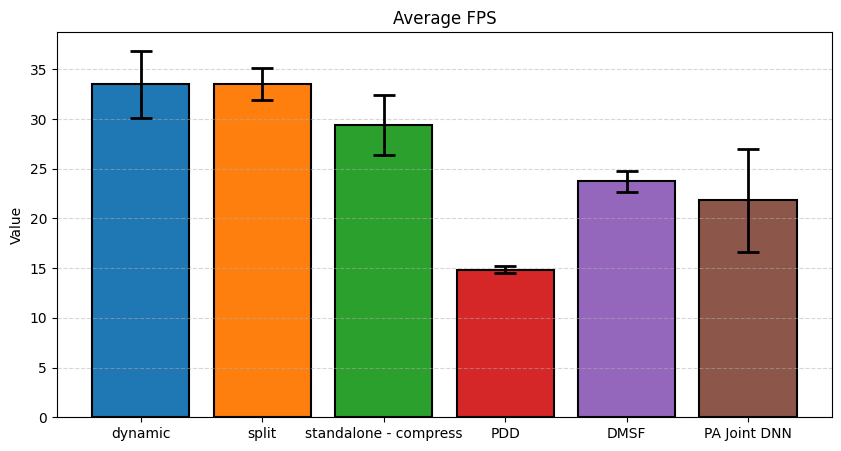

In [ ]:
indices = [0, 1, 2, 4, 6, 7]
sub_data = [data[i] for i in indices]
sub_labels = [labels[i] for i in indices]

analyze_all(sub_data , sub_labels)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


def analyze_and_visualize(data_list, list_name="Danh sách"):
    """Hàm tính toán Mean, Std, Var và vẽ biểu đồ trực quan hóa dữ liệu từ một list.

    Input:
        data_list (list): Danh sách các số cần tính toán và vẽ biểu đồ.
        list_name (str): Tên của danh sách (dùng để hiển thị trên biểu đồ).
    """
    # Kiểm tra nếu list rỗng thì dừng lại để tránh lỗi chia cho 0
    if not data_list:
        print("Danh sách rỗng! Không thể tính toán.")
        return

    # --- 1. TÍNH TOÁN CÁC CHỈ SỐ THỐNG KÊ ---
    mean_val = np.mean(data_list)
    std_val = np.std(data_list)
    var_val = np.var(data_list)

    print(f"--- Kết quả thống kê cho [{list_name}] ---")
    print(f"Mean (Trung bình)        : {mean_val:.4f}")
    print(f"Std (Độ lệch chuẩn)      : {std_val:.4f}")
    print(f"Var (Phương sai)         : {var_val:.4f}\n")

    # --- 2. TRỰC QUAN HÓA DỮ LIỆU ---
    # Vẽ biểu đồ đường biến động
    plt.plot(
        data_list,
        # marker="o",
        linestyle="-",
        color="b",
        markersize=4,
        label="Giá trị phần tử",
    )

    # Vẽ đường trung bình (Mean)
    plt.axhline(
        mean_val,
        color="r",
        linestyle="--",
        linewidth=1.5,
        label=f"Mean Line ({mean_val:.2f})",
    )

    # Cấu hình tiêu đề và các trục
    plt.title(f" {list_name}", fontsize=14)
    plt.xlabel("Index fontsize=12")
    plt.ylabel("Value", fontsize=12)

    # Hiển thị chú thích và lưới nền
    plt.legend()
    plt.grid(True, linestyle=":", alpha=0.6)

    # Tối ưu giao diện và hiển thị
    plt.tight_layout()
    plt.show()


# ========================================================
# VÍ DỤ CÁCH SỬ DỤNG HÀM:
# ========================================================


[dynamic] edge mean = 92.46% (n=9), cloud mean = 83.53% (n=3)
[split] edge mean = 92.60% (n=9), cloud mean = 90.12% (n=3)
[standalone] edge mean = 93.59% (n=9), cloud mean = 54.36% (n=3)
[DAG] edge mean = 92.46% (n=9), cloud mean = 82.34% (n=3)
[pa] edge mean = 94.58% (n=9), cloud mean = 71.01% (n=3)


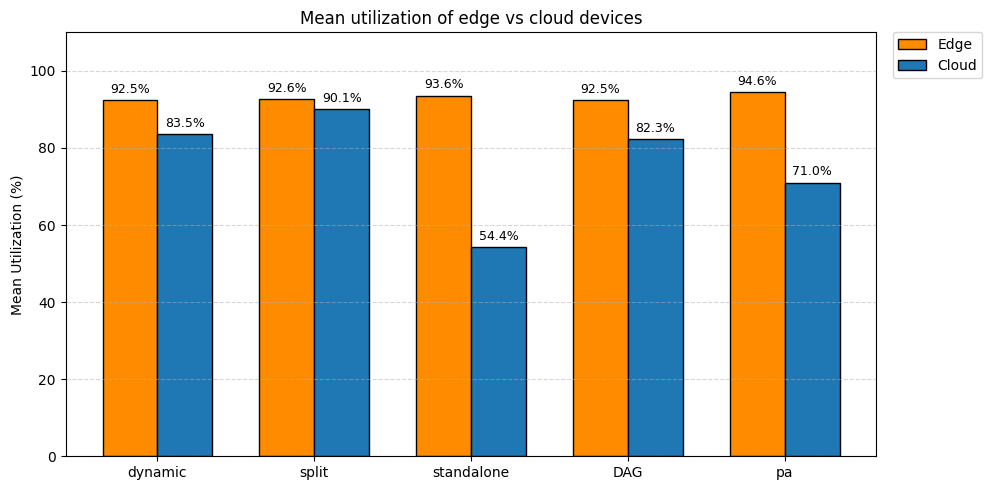

In [ ]:
import re
import os
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# CONFIG
# =========================================================
BASE_DIR = "/content/drive/MyDrive/Split Inference/result/result_afternoon_11_7"

LOG_FILES = [
    f"{BASE_DIR}/dynamic/utilization.log",
    f"{BASE_DIR}/split/utilization.log",
    f"{BASE_DIR}/standalone/utilization.log",
    f"{BASE_DIR}/DAG/utilization.log",
    f"{BASE_DIR}/pa/utilization.log",
    # f"{BASE_DIR}/qa/utilization.log",   # just uncomment to include
]

# Labels for x-axis.
#   None  -> auto-use parent folder name (dynamic, split, standalone, DAG, ...)
#   or set manually, e.g. ["Split A", "Split B", "Split C", "Split D"]
LABELS = None

SHOW_PERCENT_LABELS = True    # True = show % value on top of each bar
PERCENT_DECIMALS = 1          # decimals shown, e.g. 92.7%

EDGE_COLOR_BAR = "darkorange"
CLOUD_COLOR_BAR = "#1f77b4"
Y_LIM = (0, 110) if SHOW_PERCENT_LABELS else (0, 100)
FIG_SIZE = (max(8, 2 * len(LOG_FILES)), 5)
TITLE = "Mean utilization of edge vs cloud devices"
# =========================================================

# Auto labels from parent folder name if not provided
if LABELS is None:
    LABELS = [os.path.basename(os.path.dirname(p)) for p in LOG_FILES]

assert len(LABELS) == len(LOG_FILES), "LABELS must match number of LOG_FILES"

# ==== Parser ====
pattern = re.compile(r"role=(\w+).*?utilization=([\d.]+)%")

def parse_log(path):
    """Return dict {role: [utilization values]} for one log file."""
    data = {"edge": [], "cloud": []}
    if not os.path.exists(path):
        print(f"⚠️  File not found, skipped: {path}")
        return data
    with open(path) as f:
        for line in f:
            m = pattern.search(line)
            if m:
                role, util = m.group(1), float(m.group(2))
                if role in data:
                    data[role].append(util)
    return data

# ==== Compute means ====
edge_means, cloud_means = [], []
for path, label in zip(LOG_FILES, LABELS):
    d = parse_log(path)
    edge_mean = np.mean(d["edge"]) if d["edge"] else np.nan
    cloud_mean = np.mean(d["cloud"]) if d["cloud"] else np.nan
    edge_means.append(edge_mean)
    cloud_means.append(cloud_mean)
    print(f"[{label}] edge mean = {edge_mean:.2f}% (n={len(d['edge'])}), "
          f"cloud mean = {cloud_mean:.2f}% (n={len(d['cloud'])})")

# ==== Plot ====
x = np.arange(len(LABELS))
width = 0.35

fig, ax = plt.subplots(figsize=FIG_SIZE)
bars_edge = ax.bar(x - width/2, edge_means, width, label="Edge",
                   color=EDGE_COLOR_BAR, edgecolor="black")
bars_cloud = ax.bar(x + width/2, cloud_means, width, label="Cloud",
                    color=CLOUD_COLOR_BAR, edgecolor="black")

# Optional percentage labels on top of bars
if SHOW_PERCENT_LABELS:
    for bars in (bars_edge, bars_cloud):
        for bar in bars:
            h = bar.get_height()
            if not np.isnan(h):
                ax.annotate(f"{h:.{PERCENT_DECIMALS}f}%",
                            xy=(bar.get_x() + bar.get_width() / 2, h),
                            xytext=(0, 3), textcoords="offset points",
                            ha="center", va="bottom", fontsize=9)


OUTPUT_PATH = "utilization_chart.png"
ax.set_xticks(x)
ax.set_xticklabels(LABELS)
ax.set_ylabel("Mean Utilization (%)")
ax.set_ylim(*Y_LIM)
# ax.legend()
ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0,
    frameon=True
)

plt.tight_layout(rect=[0, 0, 0.88, 1])   # chừa khoảng trống bên phải
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.title(TITLE)
plt.tight_layout()
plt.savefig(OUTPUT_PATH, dpi=300, bbox_inches="tight")
plt.show()

# Size message based on time line

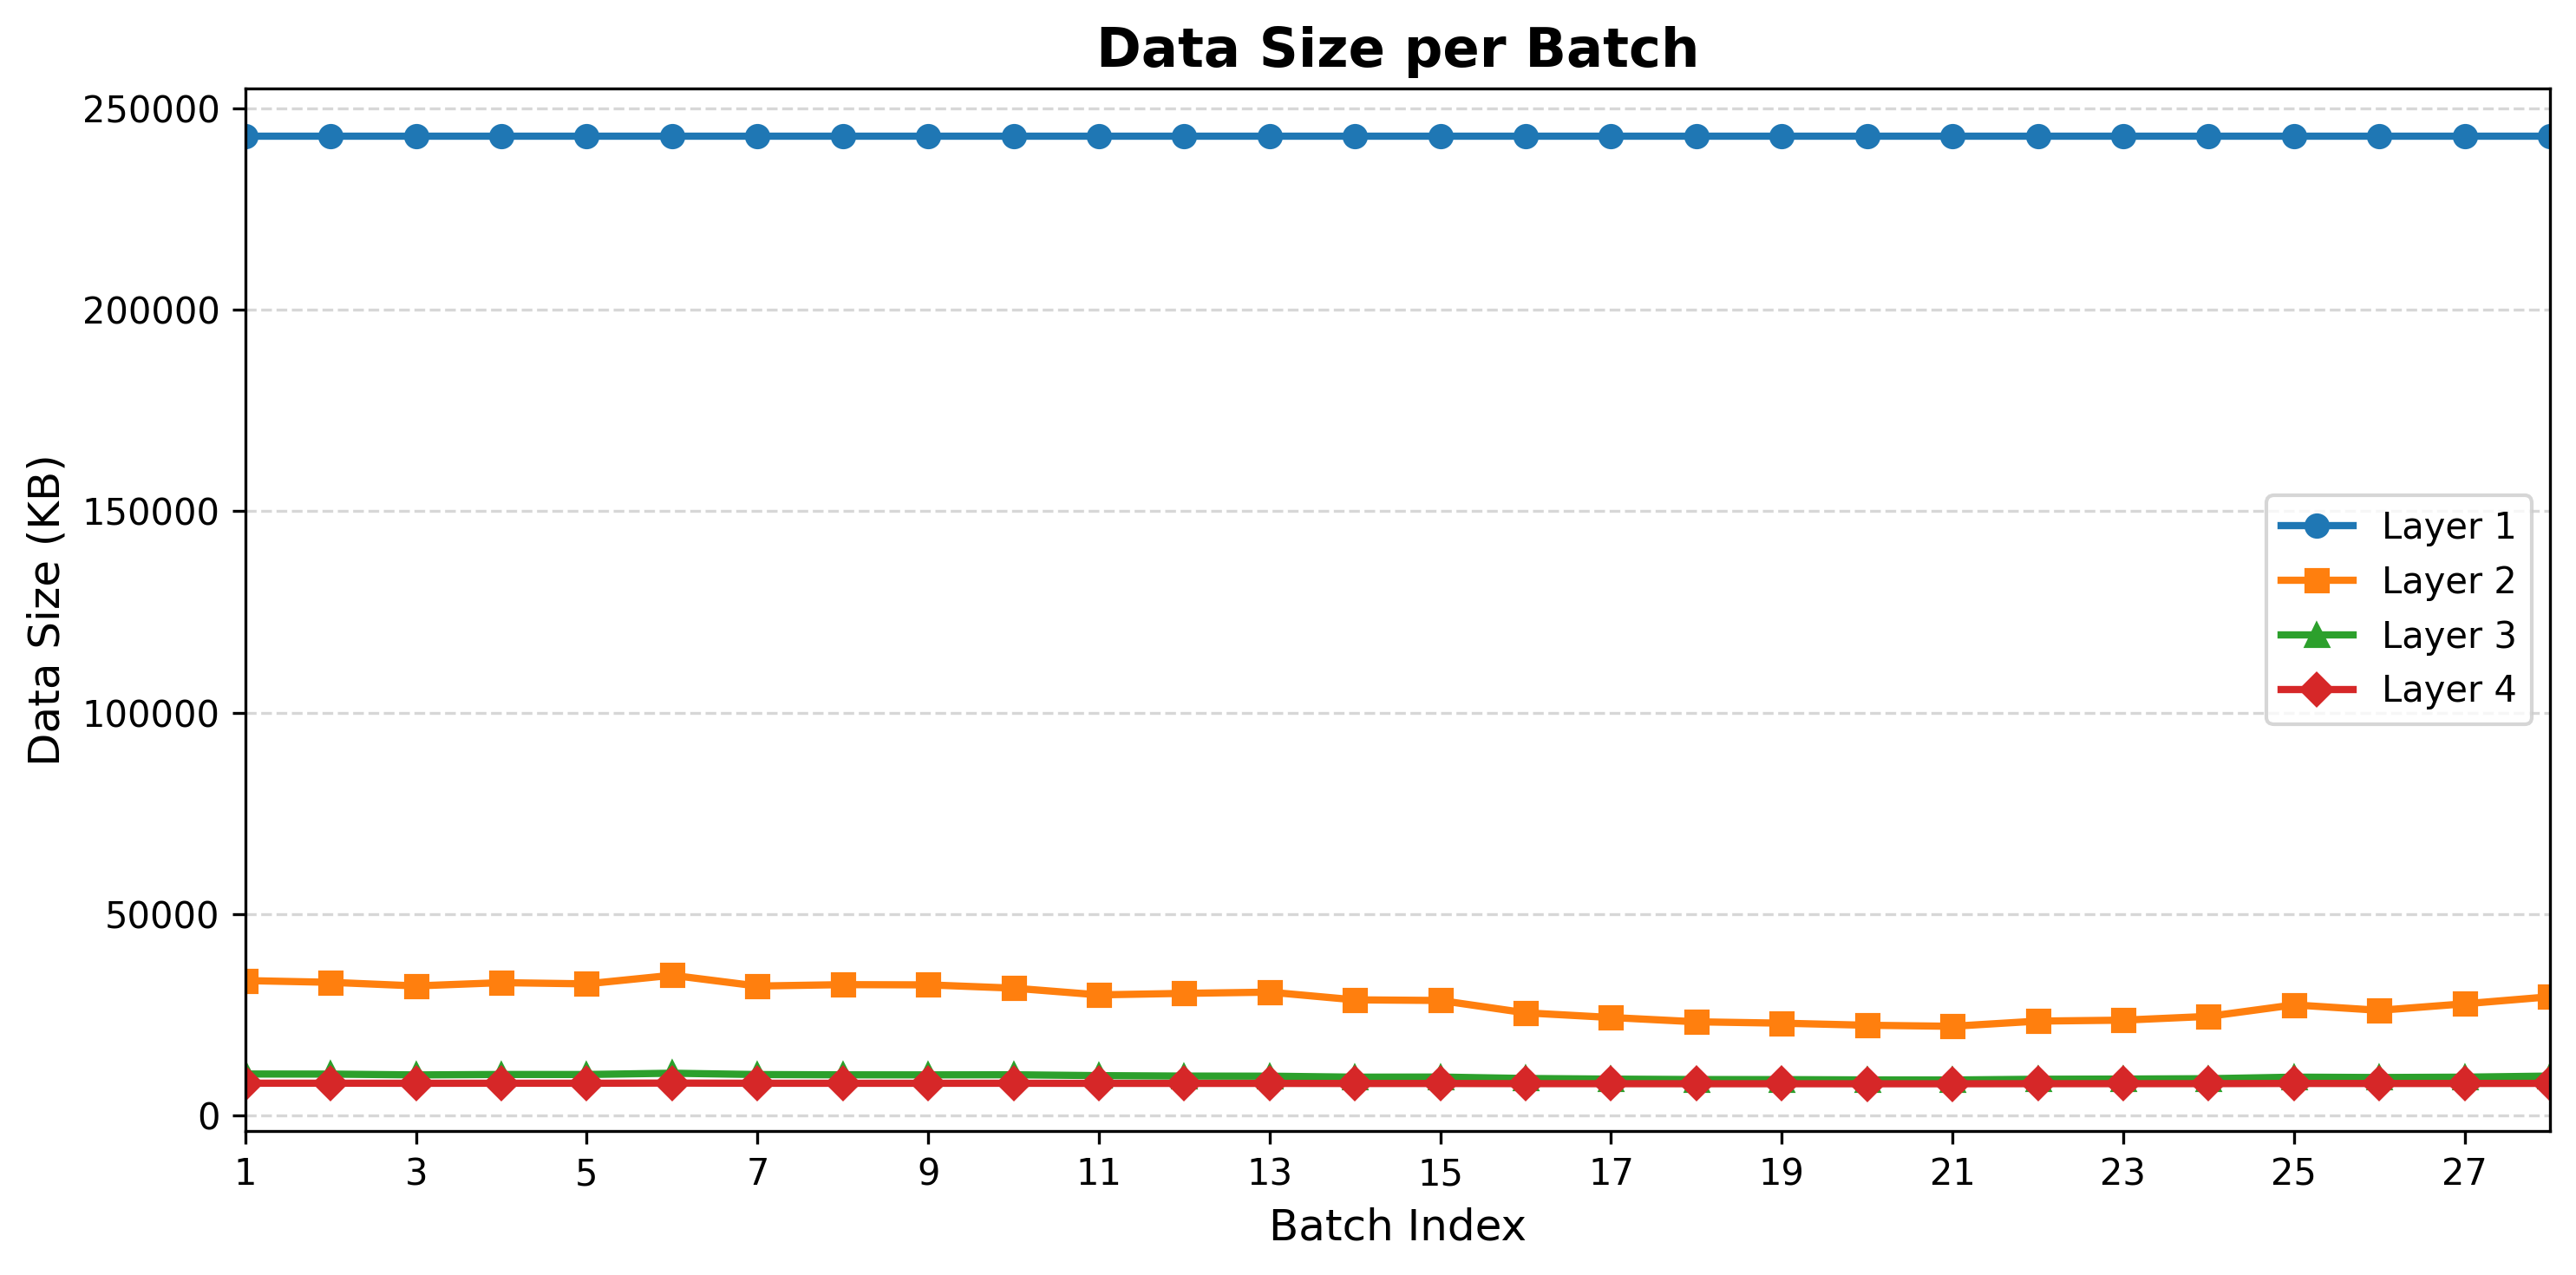

In [ ]:
import matplotlib.pyplot as plt

# ==========================
# Original data (Bytes)
# ==========================

col1 = [
    249038281.00, 249038281.00, 249038281.00, 249038281.00,
    249038281.00, 249038281.00, 249038281.00, 249038281.00,
    249038281.00, 249038281.00, 249038281.00, 249038281.00,
    249038281.00, 249038281.00, 249038281.00, 249038281.00,
    249038281.00, 249038281.00, 249038281.00, 249038281.00,
    249038281.00, 249038281.00, 249038281.00, 249038281.00,
    249038281.00, 249038281.00, 249038281.00, 249038281.00
]

col2 = [
    34303178, 33857839, 32945126, 33775589,
    33468063, 35651112, 32915858, 33269780,
    33213265, 32380439, 30668470, 31052906,
    31365896, 29406376, 29245151, 26104157,
    24919144, 23824527, 23475307, 22945704,
    22682977, 24003091, 24239985, 25202852,
    28128098, 26744222, 28400563, 30190260
]

col3 = [
    10553367, 10529983, 10321056, 10433605,
    10425712, 10754223, 10413106, 10340819,
    10331789, 10357010, 10142041, 10029107,
    10003426, 9750842, 9780578, 9415527,
    9254771, 9143869, 9124820, 9049233,
    9029622, 9221352, 9266386, 9357685,
    9754439, 9663669, 9750789, 10026844
]

col4 = [
    8216075, 8214768, 8194497, 8208281,
    8203993, 8247713, 8203312, 8194296,
    8195678, 8200519, 8176126, 8166899,
    8165169, 8137603, 8140352, 8104271,
    8089320, 8079480, 8077802, 8070984,
    8070296, 8093823, 8096311, 8105447,
    8150251, 8136000, 8145661, 8173894
]

# ==========================
# Convert Bytes -> KB
# ==========================

col1_kb = [x / 1024 for x in col1]
col2_kb = [x / 1024 for x in col2]
col3_kb = [x / 1024 for x in col3]
col4_kb = [x / 1024 for x in col4]

x = list(range(1, len(col1_kb) + 1))

plt.figure(figsize=(10,5), dpi=300)

plt.plot(x, col1_kb, marker='o', linewidth=2, label='Layer 1')
plt.plot(x, col2_kb, marker='s', linewidth=2, label='Layer 2')
plt.plot(x, col3_kb, marker='^', linewidth=2, label='Layer 3')
plt.plot(x, col4_kb, marker='D', linewidth=2, label='Layer 4')

plt.title(
    "Data Size per Batch",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Batch Index", fontsize=12)
plt.ylabel("Data Size (KB)", fontsize=12)

plt.xticks(range(1, len(x)+1, 2))
plt.xlim(1, len(x))

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.legend()

plt.tight_layout()
plt.savefig("data_size_per_batch_kb.png", dpi=300, bbox_inches="tight")
plt.show()

NameError: name 'handles' is not defined

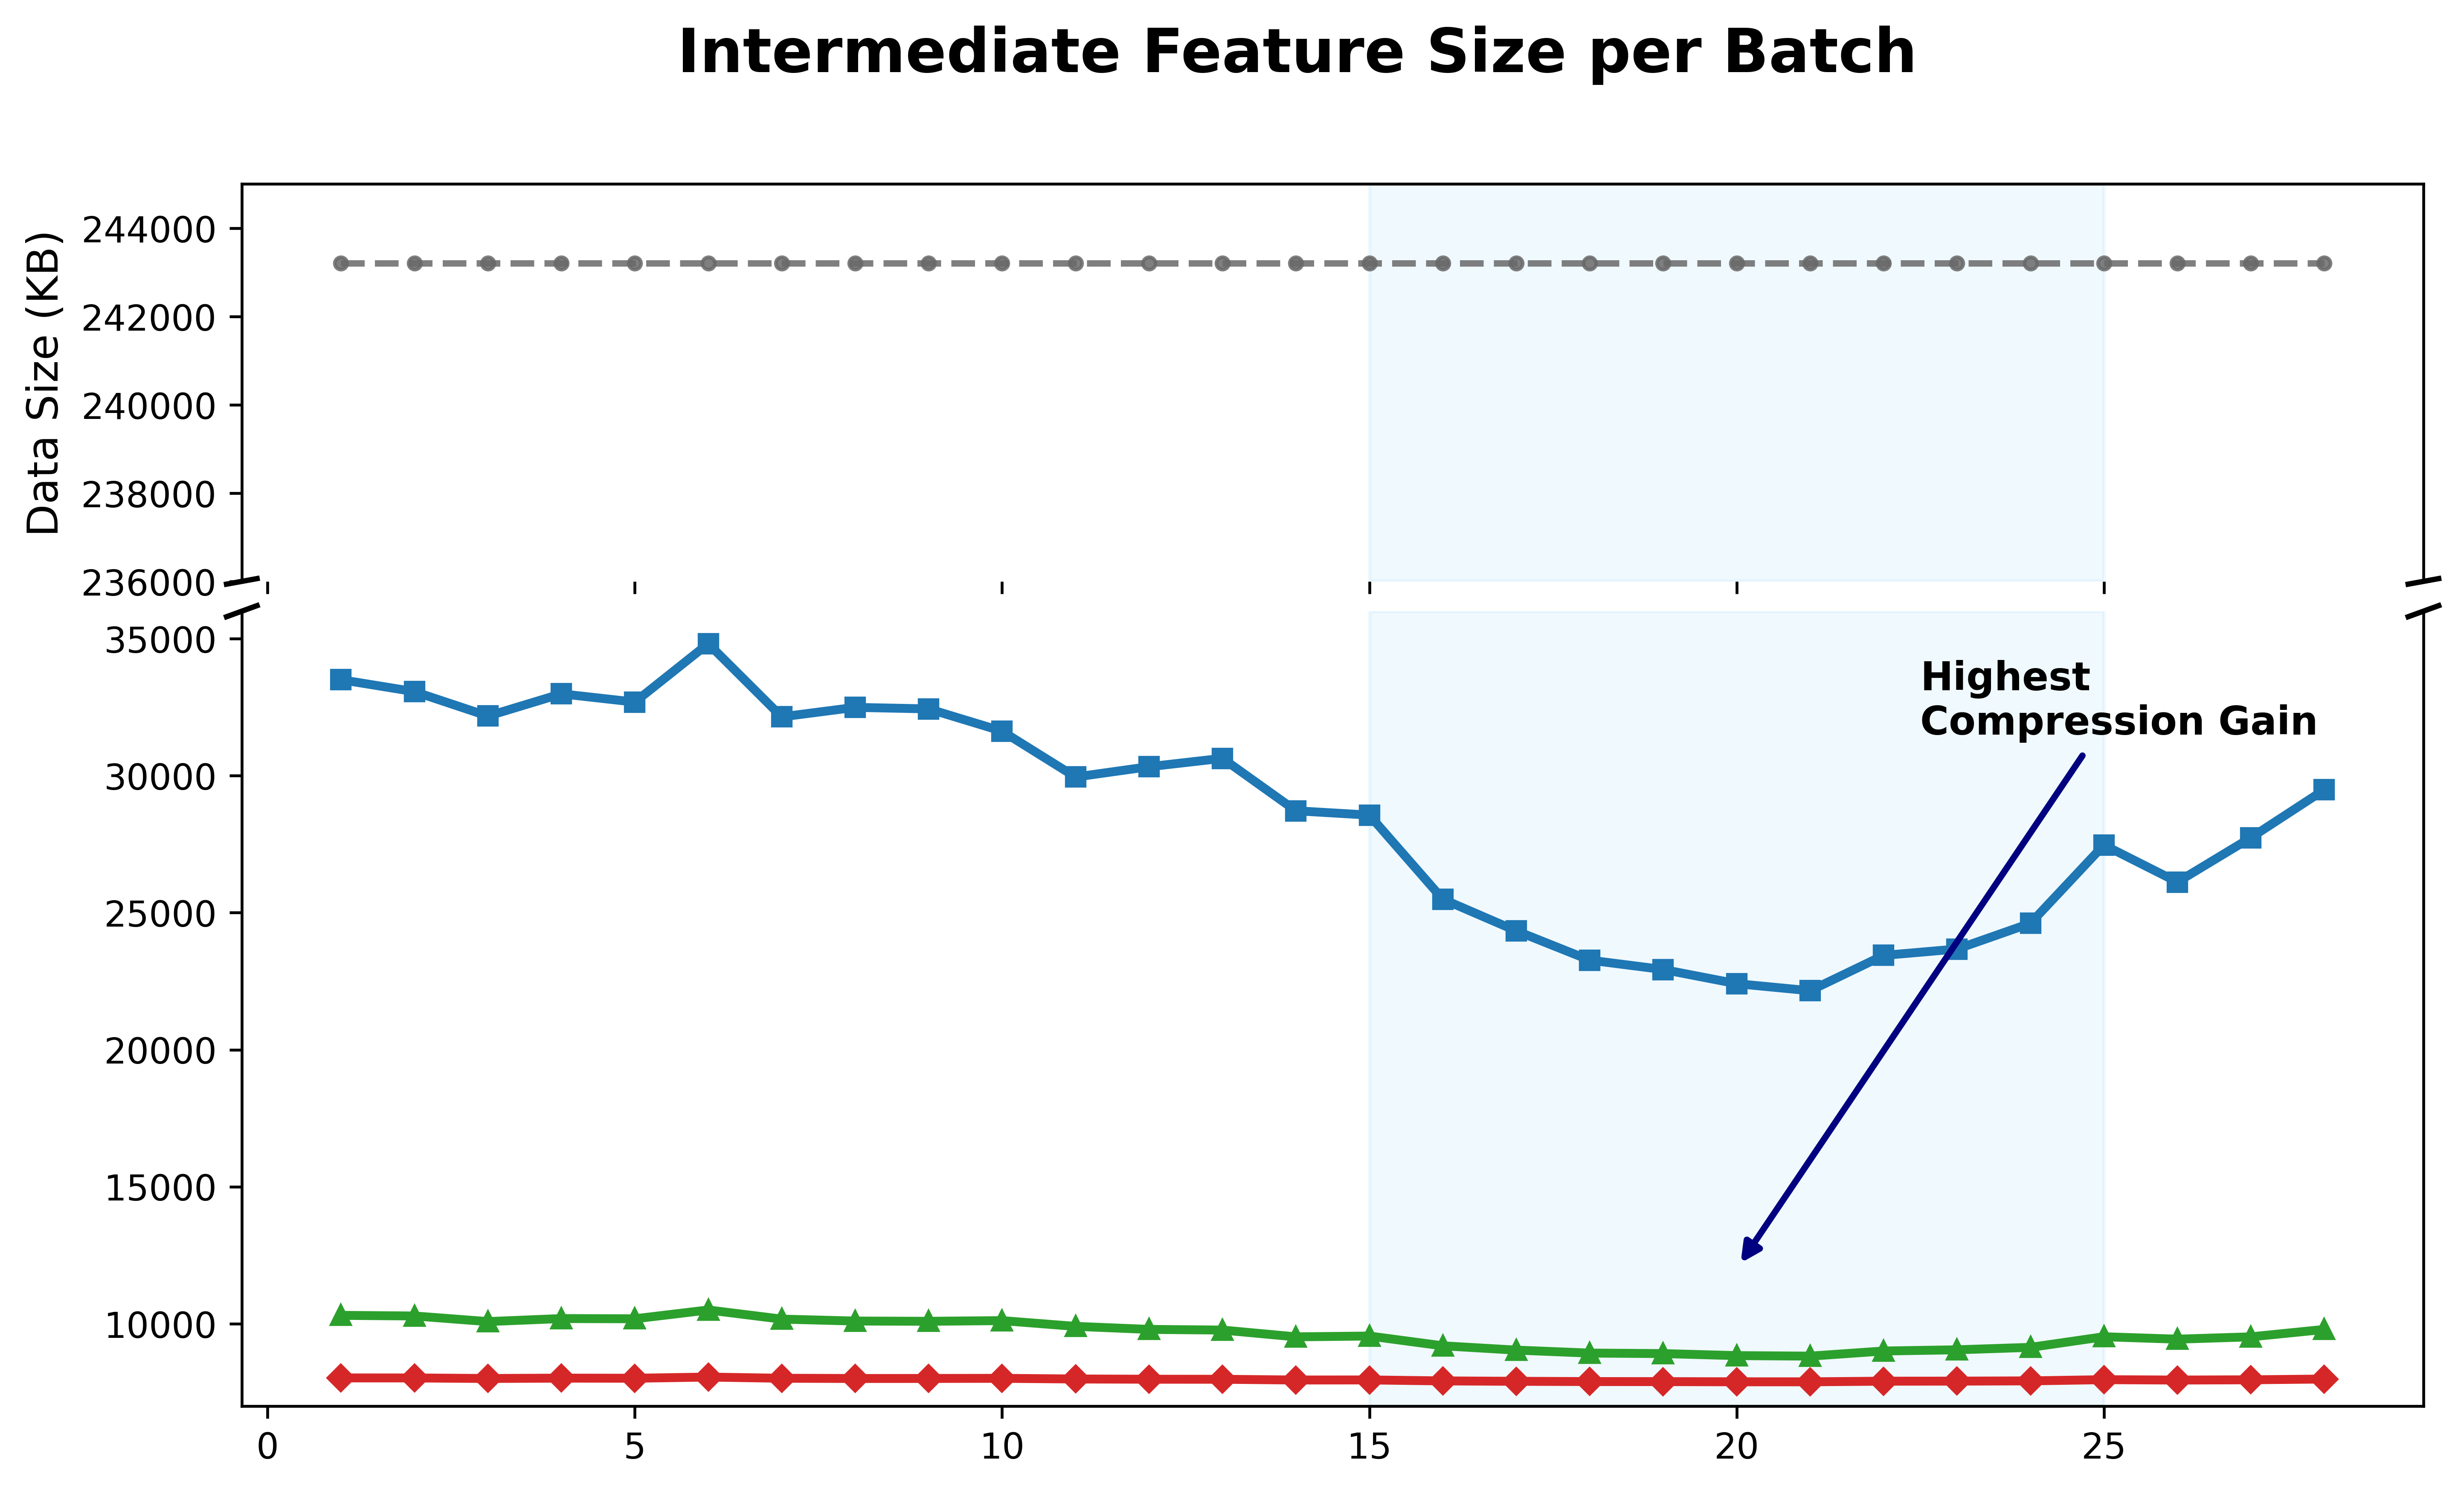

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# ======================================================
# Convert Byte -> KB
# ======================================================

# Nếu dữ liệu hiện đang là Byte thì dùng:
#
# col1_kb = [x / 1024 for x in col1]
# col2_kb = [x / 1024 for x in col2]
# col3_kb = [x / 1024 for x in col3]
# col4_kb = [x / 1024 for x in col4]

x = list(range(1, len(col1_kb)+1))

# ======================================================
# Figure
# ======================================================

fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    figsize=(11,6.2),
    dpi=600,
    sharex=True,
    gridspec_kw={
        "height_ratios":[1,2],
        "hspace":0.05
    }
)

# ======================================================
# Original (No Compression)
# ======================================================

for ax in [ax1, ax2]:

    ax.plot(
        x,
        col1_kb,
        color="dimgray",
        linestyle="--",
        linewidth=1.8,
        marker="o",
        markersize=3.5,
        alpha=0.85,
        label="No Compression"
    )

# ======================================================
# Quantized versions
# ======================================================

colors = [
    "#1f77b4",      # Blue
    "#2ca02c",      # Green
    "#d62728"       # Red
]

markers = [
    "s",
    "^",
    "D"
]

labels = [
    "No Compression" ,
    "8 bits Quantization",
    "4 bits Quantization",
    "2 bits Quantization"
]

datas = [
    col2_kb,
    col3_kb,
    col4_kb
]

for ax in [ax1, ax2]:

    for data, color, marker, label in zip(datas, colors, markers, labels):

        ax.plot(
            x,
            data,
            color=color,
            linewidth=2.5,
            marker=marker,
            markersize=5,
            label=label
        )

# ======================================================
# Highlight important region
# ======================================================

for ax in [ax1, ax2]:

    ax.axvspan(
        15,
        25,
        color="lightskyblue",
        alpha=0.12,
        zorder=0
    )

# ======================================================
# Broken Y-axis
# ======================================================

ax1.set_ylim(236000,245000)

ax2.set_ylim(7000,36000)

# ======================================================
# Hide spines
# ======================================================

ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)

ax1.tick_params(labeltop=False)

# ======================================================
# Break marks
# ======================================================

d = 0.007

kwargs = dict(
    transform=ax1.transAxes,
    color='black',
    clip_on=False
)

ax1.plot((-d,+d),(-d,+d), **kwargs)
ax1.plot((1-d,1+d),(-d,+d), **kwargs)

kwargs.update(transform=ax2.transAxes)

ax2.plot((-d,+d),(1-d,1+d), **kwargs)
ax2.plot((1-d,1+d),(1-d,1+d), **kwargs)

# ======================================================
# Dashed rectangle
# ======================================================

# rect = Rectangle(
#     (15,7000),
#     10,
#     29000,
#     linewidth=2,
#     edgecolor="navy",
#     linestyle="--",
#     facecolor="none"
# )

# ax2.add_patch(rect)

# ======================================================
# Annotation
# ======================================================

ax2.annotate(
    "Highest\nCompression Gain",
    xy=(20,12000),
    xytext=(22.5,31500),

    fontsize=11,
    fontweight="bold",

    arrowprops=dict(
        arrowstyle="-|>",
        lw=1.8,
        color="navy"
    )
)

# ======================================================
# Labels
# ======================================================

plt.suptitle(
    "Intermediate Feature Size per Batch",
    fontsize=17,
    fontweight="bold"
)

ax1.set_ylabel(
    "Data Size (KB)",
    fontsize=12
)

ax1.legend(
    handles,
    labels,
    loc='center',
    bbox_to_anchor=(0.25,0.35),
    ncol=2,
    frameon=True,
    fontsize=10
)

ax2.set_ylabel(
    "Data Size (KB)",
    fontsize=12
)

ax2.set_xlabel(
    "Batch Index",
    fontsize=12
)


# ======================================================
# Grid
# ======================================================

for ax in [ax1, ax2]:

    ax.grid(
        axis='y',
        linestyle='--',
        linewidth=0.7,
        alpha=0.4
    )

# ======================================================
# Legend
# ======================================================

handles, labels = ax2.get_legend_handles_labels()

# ax2.legend(
#     handles,
#     labels,
#     loc="upper left",
#     fontsize=10,
#     frameon=True,
#     framealpha=0.95
# )

# ======================================================
# X-axis
# ======================================================

ax2.set_xlim(1, len(x))

ax2.set_xticks(range(1, len(x)+1, 2))

# ======================================================
# Tick size
# ======================================================

ax1.tick_params(axis='both', labelsize=10)

ax2.tick_params(axis='both', labelsize=10)

# ======================================================
# Save
# ======================================================

plt.tight_layout()

plt.savefig(
    "feature_size_quantization_ieee.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# mAP


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
cluster
intermediate_queue_0    14
intermediate_queue_1    14
test_local              14
dtype: int64


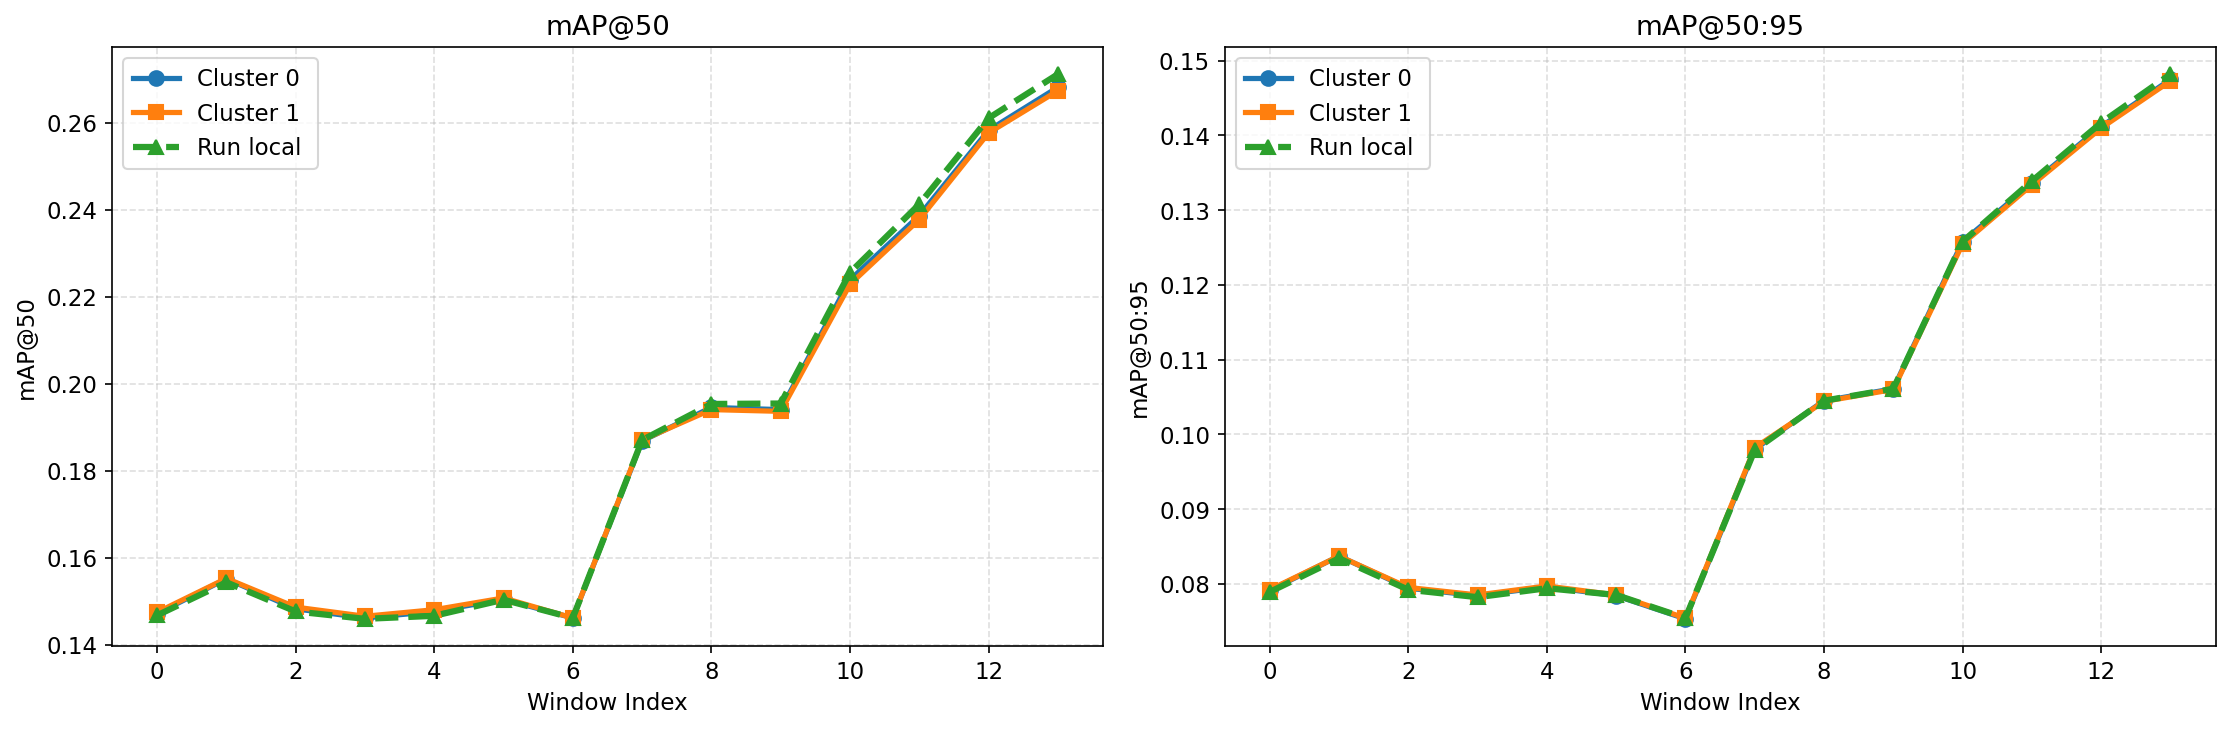

In [ ]:
# ============================================================
# Visualize mAP50 & mAP50-95 by Window
# - Read intermediate_queue_* from log file
# - Add test_local from pasted text
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import re
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CONFIG
# ============================================================

FILE_PATH = "/content/drive/MyDrive/Split Inference/result/mAP/map_window.log"

# True  -> 2 charts (mAP50 + mAP50-95)
# False -> only mAP50
config_mode = True

SAVE_FIG = False
SAVE_NAME = "mAP_window.png"

plt.rcParams["figure.dpi"] = 150
plt.rcParams["font.size"] = 11

# ============================================================
# Read original log
# ============================================================

pattern = re.compile(
    r"cluster=(\S+)\s+window=(\d+).*?mAP50_95=([0-9.]+)\s+mAP50=([0-9.]+)"
)

rows = []

with open(FILE_PATH, "r") as f:
    for line in f:
        m = pattern.search(line)
        if m:
            rows.append({
                "cluster": m.group(1),
                "window": int(m.group(2)),
                "mAP50_95": float(m.group(3)),
                "mAP50": float(m.group(4))
            })

# ============================================================
# Paste test_local here
# ============================================================

test_local_log = """
1785058640613117500 cluster=test_local window=0 batches=0-15 frames=512 mAP50_95=0.0789 mAP50=0.1468
1785058640613117500 cluster=test_local window=1 batches=1-16 frames=512 mAP50_95=0.0834 mAP50=0.1544
1785058640613117500 cluster=test_local window=2 batches=2-17 frames=512 mAP50_95=0.0792 mAP50=0.1477
1785058640613117500 cluster=test_local window=3 batches=3-18 frames=512 mAP50_95=0.0782 mAP50=0.1460
1785058640613117500 cluster=test_local window=4 batches=4-19 frames=512 mAP50_95=0.0794 mAP50=0.1467
1785058640613117500 cluster=test_local window=5 batches=5-20 frames=512 mAP50_95=0.0785 mAP50=0.1504
1785058640613117500 cluster=test_local window=6 batches=6-21 frames=512 mAP50_95=0.0754 mAP50=0.1462
1785058640613117500 cluster=test_local window=7 batches=7-22 frames=512 mAP50_95=0.0979 mAP50=0.1871
1785058640613117500 cluster=test_local window=8 batches=8-23 frames=512 mAP50_95=0.1045 mAP50=0.1954
1785058640613117500 cluster=test_local window=9 batches=9-24 frames=512 mAP50_95=0.1061 mAP50=0.1955
1785058640613117500 cluster=test_local window=10 batches=10-25 frames=512 mAP50_95=0.1258 mAP50=0.2256
1785058640613117500 cluster=test_local window=11 batches=11-26 frames=512 mAP50_95=0.1339 mAP50=0.2413
1785058640613117500 cluster=test_local window=12 batches=12-27 frames=512 mAP50_95=0.1417 mAP50=0.2611
1785058640613117500 cluster=test_local window=13 batches=13-28 frames=489 mAP50_95=0.1482 mAP50=0.2712
"""

for line in test_local_log.strip().splitlines():
    m = pattern.search(line)
    if m:
        rows.append({
            "cluster": m.group(1),
            "window": int(m.group(2)),
            "mAP50_95": float(m.group(3)),
            "mAP50": float(m.group(4))
        })

# ============================================================
# DataFrame
# ============================================================

df = pd.DataFrame(rows)

print(df.groupby("cluster").size())

# ============================================================
# Style
# ============================================================

style_map = {
    "intermediate_queue_0": {
        "marker": "o",
        "linewidth": 2.5,
        "linestyle": "-",
        "label": "Cluster 0"
    },
    "intermediate_queue_1": {
        "marker": "s",
        "linewidth": 2.5,
        "linestyle": "-",
        "label": "Cluster 1"
    },
    "test_local": {
        "marker": "^",
        "linewidth": 3,
        "linestyle": "--",
        "label": "Run local "
    }
}

plot_order = [
    "intermediate_queue_0",
    "intermediate_queue_1",
    "test_local"
]

# ============================================================
# Plot
# ============================================================

if config_mode:

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # ---------------- mAP50 ----------------

    for cluster in plot_order:

        tmp = df[df.cluster == cluster].sort_values("window")

        if len(tmp) == 0:
            continue

        style = style_map[cluster]

        axes[0].plot(
            tmp.window,
            tmp.mAP50,
            marker=style["marker"],
            linestyle=style["linestyle"],
            linewidth=style["linewidth"],
            markersize=7,
            label=style["label"]
        )

    axes[0].set_title("mAP@50")
    axes[0].set_xlabel("Window Index")
    axes[0].set_ylabel("mAP@50")
    axes[0].grid(True, linestyle="--", alpha=0.4)
    axes[0].legend()

    # ---------------- mAP50-95 ----------------

    for cluster in plot_order:

        tmp = df[df.cluster == cluster].sort_values("window")

        if len(tmp) == 0:
            continue

        style = style_map[cluster]

        axes[1].plot(
            tmp.window,
            tmp.mAP50_95,
            marker=style["marker"],
            linestyle=style["linestyle"],
            linewidth=style["linewidth"],
            markersize=7,
            label=style["label"]
        )

    axes[1].set_title("mAP@50:95")
    axes[1].set_xlabel("Window Index")
    axes[1].set_ylabel("mAP@50:95")
    axes[1].grid(True, linestyle="--", alpha=0.4)
    axes[1].legend()

    plt.tight_layout()

else:

    plt.figure(figsize=(8,5))

    for cluster in plot_order:

        tmp = df[df.cluster == cluster].sort_values("window")

        if len(tmp) == 0:
            continue

        style = style_map[cluster]

        plt.plot(
            tmp.window,
            tmp.mAP50,
            marker=style["marker"],
            linestyle=style["linestyle"],
            linewidth=style["linewidth"],
            markersize=7,
            label=style["label"]
        )

    plt.title("mAP@50")
    plt.xlabel("Window Index")
    plt.ylabel("mAP@50")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()

# ============================================================
# Save
# ============================================================

if SAVE_FIG:
    plt.savefig(SAVE_NAME, dpi=300, bbox_inches="tight")

plt.show()

# FPS and latency by Cluster

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


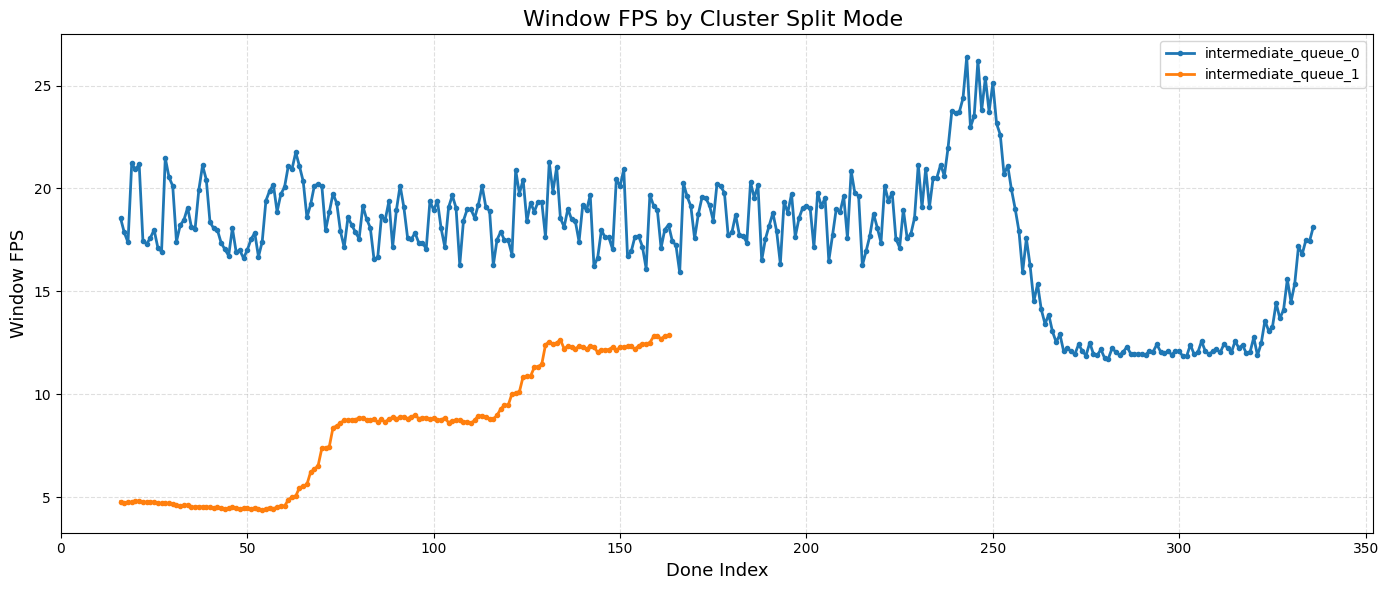

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import re
import pandas as pd
import matplotlib.pyplot as plt

# ==========================
# Path tới file log trên Google Drive
# ==========================
LOG_PATH = "/content/drive/MyDrive/Split Inference/result/fps and latency by cluster /fps_cluster_ns.log"

# ==========================
# Regex
# ==========================
pattern = re.compile(
    r"cluster=(\S+).*?done=(\d+).*?window_fps=([\d.]+)"
)

data = []

with open(LOG_PATH, "r") as f:
    for line in f:
        m = pattern.search(line)
        if m:
            cluster = m.group(1)
            done = int(m.group(2))
            fps = float(m.group(3))

            data.append({
                "cluster": cluster,
                "done": done,
                "fps": fps
            })

df = pd.DataFrame(data)

# ==========================
# Plot
# ==========================
plt.figure(figsize=(14,6))

for cluster in sorted(df["cluster"].unique()):
    sub = df[df["cluster"] == cluster].sort_values("done")

    plt.plot(
        sub["done"],
        sub["fps"],
        linewidth=2,
        marker="o",
        markersize=3,
        label=cluster
    )

plt.title("Window FPS by Cluster Split Mode ", fontsize=16)
plt.xlabel("Done Index", fontsize=13)
plt.ylabel("Window FPS", fontsize=13)

plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

## Mean Service Latency by Cluster

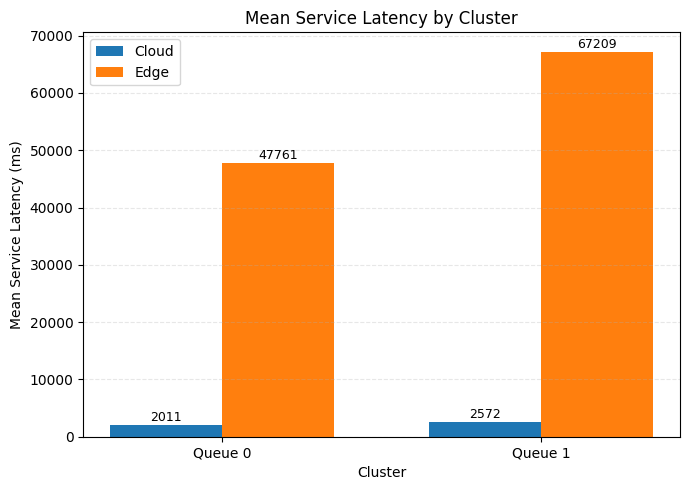

In [1]:
import matplotlib.pyplot as plt

# Mean service latency (ms)
labels = ["Queue 0", "Queue 1"]

cloud = [2011.337, 2571.708]
edge = [47761.141, 67209.294]

x = range(len(labels))
width = 0.35

plt.figure(figsize=(7, 5))

plt.bar([i - width/2 for i in x], cloud, width, label="Cloud")
plt.bar([i + width/2 for i in x], edge, width, label="Edge")

plt.xticks(x, labels)
plt.ylabel("Mean Service Latency (ms)")
plt.xlabel("Cluster")
plt.title("Mean Service Latency by Cluster")
plt.legend()

# Hiển thị giá trị trên cột
for i, v in enumerate(cloud):
    plt.text(i - width/2, v + max(edge) * 0.01, f"{v:.0f}",
             ha="center", fontsize=9)

for i, v in enumerate(edge):
    plt.text(i + width/2, v + max(edge) * 0.01, f"{v:.0f}",
             ha="center", fontsize=9)

plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

## Device Utilization by Cluster

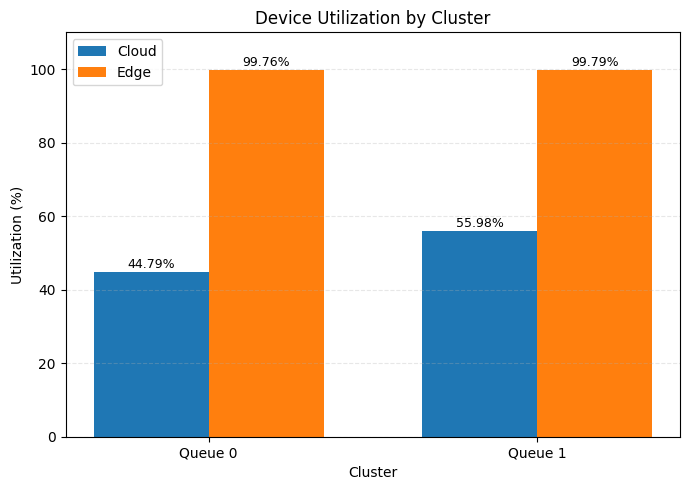

In [2]:
import matplotlib.pyplot as plt

# Utilization (%)
labels = ["Queue 0", "Queue 1"]

cloud = [44.79, 55.98]
edge = [99.76, 99.79]

x = range(len(labels))
width = 0.35

plt.figure(figsize=(7, 5))

plt.bar([i - width/2 for i in x], cloud, width, label="Cloud")
plt.bar([i + width/2 for i in x], edge, width, label="Edge")

plt.xticks(x, labels)
plt.ylabel("Utilization (%)")
plt.xlabel("Cluster")
plt.title("Device Utilization by Cluster")
plt.ylim(0, 110)
plt.legend()

# Hiển thị giá trị trên cột
for i, v in enumerate(cloud):
    plt.text(i - width/2, v + 1, f"{v:.2f}%",
             ha="center", fontsize=9)

for i, v in enumerate(edge):
    plt.text(i + width/2, v + 1, f"{v:.2f}%",
             ha="center", fontsize=9)

plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()